# Phase 2 — Text Vectorization (Feature Extraction)

**Goal:** Convert the cleaned Persian text into numerical feature matrices using three methods:

| Method | Type | Vector | Key idea |
|---|---|---|---|
| `CountVectorizer` | Sparse | high-dim | Raw word / bigram occurrence counts |
| `TF-IDF` | Sparse | high-dim | Count weighted by inverse document frequency |
| `Word2Vec` (trained from scratch) | Dense | 100-dim | Semantic embeddings trained on our corpus |

All feature matrices are saved to `data/processed/` for Phase 3.

In [1]:
import sys, os
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
for p in [REPO_ROOT, os.path.join(REPO_ROOT, 'src')]:
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec
from vectorizers import MeanWord2VecVectorizer, oov_rate

DATA_PROC = os.path.join(REPO_ROOT, 'data', 'processed')
MODEL_DIR = os.path.join(REPO_ROOT, 'models', 'word2vec')
FIG_DIR   = os.path.join(REPO_ROOT, 'outputs', 'figures')
os.makedirs(MODEL_DIR, exist_ok=True)

print('Imports OK')

Imports OK


## 1. Load Processed Data

In [2]:
train_df = pd.read_csv(os.path.join(DATA_PROC, 'train.csv'), encoding='utf-8')
test_df  = pd.read_csv(os.path.join(DATA_PROC, 'test.csv'),  encoding='utf-8')

# Fill any NaN that may have survived
train_df['cleaned'] = train_df['cleaned'].fillna('').astype(str)
test_df['cleaned']  = test_df['cleaned'].fillna('').astype(str)

X_train = train_df['cleaned'].values
X_test  = test_df['cleaned'].values
y_train = np.load(os.path.join(DATA_PROC, 'y_train.npy'))
y_test  = np.load(os.path.join(DATA_PROC, 'y_test.npy'))

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

Train: 55,577 | Test: 13,895


## 2. CountVectorizer

The simplest approach: build a vocabulary from the corpus, then represent each document
as a vector of word/bigram **counts**.

**Settings chosen:**
- `max_features=50000` — keeps the 50k most frequent n-grams; caps memory at a sensible level
- `ngram_range=(1, 2)` — includes unigrams *and* bigrams; bigrams capture sentiment phrases
  like `خیلی خوب` (very good) or `اصلا خوب` (not good at all) as single features
- `min_df=2` — discard n-grams that appear in fewer than 2 documents (hapax legomena add
  noise and bloat vocabulary without helping classification)

In [3]:
count_vec = CountVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    min_df=2,
)

X_train_count = count_vec.fit_transform(X_train)
X_test_count  = count_vec.transform(X_test)

print(f'CountVectorizer vocab size : {len(count_vec.vocabulary_):,}')
print(f'Train matrix shape         : {X_train_count.shape}')
print(f'Test  matrix shape         : {X_test_count.shape}')
print(f'Sparsity                   : {1 - X_train_count.nnz / (X_train_count.shape[0] * X_train_count.shape[1]):.4%}')

CountVectorizer vocab size : 50,000
Train matrix shape         : (55577, 50000)
Test  matrix shape         : (13895, 50000)
Sparsity                   : 99.9682%


In [4]:
# Top 20 most frequent unigrams
feature_names = count_vec.get_feature_names_out()
total_counts  = np.asarray(X_train_count.sum(axis=0)).flatten()
top20_idx     = total_counts.argsort()[::-1][:20]

print('Top 20 most frequent features (CountVectorizer):')
for i, idx in enumerate(top20_idx):
    print(f'  {i+1:>2}. {feature_names[idx]:<20}  count={int(total_counts[idx]):,}')

Top 20 most frequent features (CountVectorizer):
   1. غذا                   count=13,189
   2. کیفیت                 count=12,324
   3. خوب                   count=11,275
   4. عالی                  count=10,732
   5. سفارش                 count=10,145
   6. داد                   count=7,121
   7. پیتزا                 count=6,704
   8. داشت                  count=5,913
   9. واقعا                 count=5,578
  10. ممنون                 count=5,461
  11. اصلا                  count=5,403
  12. سرد                   count=5,377
  13. خوشمزه                count=4,967
  14. ارسال                 count=4,955
  15. طعم                   count=4,709
  16. مرغ                   count=4,056
  17. بد                    count=4,017
  18. پیک                   count=3,934
  19. تازه                  count=3,918
  20. شده                   count=3,853


In [5]:
# Save sparse matrix
sp.save_npz(os.path.join(DATA_PROC, 'X_train_count.npz'), X_train_count)
sp.save_npz(os.path.join(DATA_PROC, 'X_test_count.npz'),  X_test_count)
print('CountVectorizer matrices saved.')

CountVectorizer matrices saved.


## 3. TF-IDF

TF-IDF improves on raw counts by **downweighting very common words** (which carry little
discriminative information) and **upweighting rare, informative words**.

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \log\frac{N}{\text{df}(t)}$$

**Settings chosen:**
- `max_features=50000`, `ngram_range=(1, 2)`, `min_df=2` — same reasoning as CountVectorizer
- `sublinear_tf=True` — applies `tf = 1 + log(tf)` instead of raw count;
  prevents a word repeated 50× from dominating a review's vector vs. one repeated 5×

In [6]:
tfidf_vec = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)

X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf  = tfidf_vec.transform(X_test)

print(f'TF-IDF vocab size  : {len(tfidf_vec.vocabulary_):,}')
print(f'Train matrix shape : {X_train_tfidf.shape}')
print(f'Test  matrix shape : {X_test_tfidf.shape}')
print(f'Sparsity           : {1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.4%}')

TF-IDF vocab size  : 50,000
Train matrix shape : (55577, 50000)
Test  matrix shape : (13895, 50000)
Sparsity           : 99.9682%


In [7]:
# Top 20 by highest mean TF-IDF weight across training documents
tfidf_names   = tfidf_vec.get_feature_names_out()
mean_tfidf    = np.asarray(X_train_tfidf.mean(axis=0)).flatten()
top20_tfidf   = mean_tfidf.argsort()[::-1][:20]

print('Top 20 features by mean TF-IDF weight:')
for i, idx in enumerate(top20_tfidf):
    print(f'  {i+1:>2}. {tfidf_names[idx]:<20}  mean_weight={mean_tfidf[idx]:.5f}')

Top 20 features by mean TF-IDF weight:
   1. عالی                  mean_weight=0.02546
   2. خوب                   mean_weight=0.02242
   3. غذا                   mean_weight=0.02222
   4. کیفیت                 mean_weight=0.02190
   5. سفارش                 mean_weight=0.01525
   6. ممنون                 mean_weight=0.01512
   7. سرد                   mean_weight=0.01449
   8. خوشمزه                mean_weight=0.01431
   9. پیتزا                 mean_weight=0.01325
  10. داد                   mean_weight=0.01217
  11. واقعا                 mean_weight=0.01115
  12. داشت                  mean_weight=0.01101
  13. تازه                  mean_weight=0.01101
  14. اصلا                  mean_weight=0.01082
  15. ارسال                 mean_weight=0.01072
  16. طعم                   mean_weight=0.01031
  17. بد                    mean_weight=0.00935
  18. قیمت                  mean_weight=0.00896
  19. پیک                   mean_weight=0.00867
  20. مرغ                   mean_weight=0.00859


In [8]:
sp.save_npz(os.path.join(DATA_PROC, 'X_train_tfidf.npz'), X_train_tfidf)
sp.save_npz(os.path.join(DATA_PROC, 'X_test_tfidf.npz'),  X_test_tfidf)
print('TF-IDF matrices saved.')

TF-IDF matrices saved.


## 4. Word2Vec (Trained from Scratch)

Word2Vec learns **dense vector representations** (embeddings) where semantically similar
words are close in vector space.  Unlike CountVectorizer/TF-IDF, it captures meaning:
`خوب` (good) and `عالی` (excellent) would be nearby.

**We train from scratch** on our own corpus (no pretrained model) because:
1. The project specification requires it
2. Food/delivery domain vocabulary (سفارش, تحویل, رستوران) is well represented in 70k reviews

**Document vector strategy:** average all word vectors in a review.  Simple mean works
well for sentiment because emotional signal is distributed across the whole text.

**Settings chosen:**
- `vector_size=100` — appropriate for a 70k corpus; 300d would be underfit
- `sg=1` (Skip-gram) — better than CBOW for smaller corpora and rare words
- `window=5` — context window of 5 words captures local sentiment context
- `min_count=2` — drop words seen fewer than twice (pure noise)
- `epochs=15` — enough passes for convergence without overfitting

In [9]:
# Prepare tokenized corpus (gensim expects list of lists of strings)
tokenized_train = [text.split() for text in X_train]
tokenized_test  = [text.split() for text in X_test]

print(f'Training corpus: {len(tokenized_train):,} documents')
print(f'Sample tokens from doc 0: {tokenized_train[0][:10]}')

Training corpus: 55,577 documents
Sample tokens from doc 0: ['یکم', 'خام', 'کیفیت', 'قبلو', 'داشت']


In [10]:
print('Training Word2Vec... (takes ~30-60 seconds)')

w2v_model = Word2Vec(
    sentences=tokenized_train,
    vector_size=100,
    window=5,
    min_count=2,
    sg=1,          # Skip-gram
    workers=4,
    epochs=15,
    seed=42,
)

print(f'Vocabulary size: {len(w2v_model.wv):,} words')
print(f'Vector size    : {w2v_model.vector_size}')

Training Word2Vec... (takes ~30-60 seconds)


Vocabulary size: 10,105 words
Vector size    : 100


In [11]:
# Save model
w2v_path = os.path.join(MODEL_DIR, 'persian_w2v.model')
w2v_model.save(w2v_path)
print(f'Model saved to {w2v_path}')

Model saved to E:\University\University_Subjects\6th\Computational_Intelligence\Projects\3\NLP-Ensemble\models\word2vec\persian_w2v.model


In [12]:
# Sanity check: most similar words to key sentiment terms
probe_words = ['خوب', 'بد', 'غذا', 'سفارش']
for w in probe_words:
    if w in w2v_model.wv:
        similar = w2v_model.wv.most_similar(w, topn=5)
        sim_str = ', '.join([f'{s[0]}({s[1]:.2f})' for s in similar])
        print(f'  {w}: {sim_str}')
    else:
        print(f'  {w}: NOT in vocabulary')

  خوب: عالی(0.81), عاالی(0.78), حوب(0.75), زغالی(0.73), وب(0.72)
  بد: ونپخته(0.78), افتضاح(0.78), افتضااح(0.74), ترش‌مزه(0.73), نتوستیم(0.73)
  غذا: غدا(0.77), عذا(0.76), هاب(0.74), فذا(0.73), غذابا(0.73)
  سفارش: سفارس(0.72), شفار(0.70), غذاسفارش(0.68), بهتربود(0.65), خدانگهدار(0.65)


In [13]:
# OOV diagnostic
train_oov = oov_rate(X_train, w2v_model)
test_oov  = oov_rate(X_test,  w2v_model)
print(f'OOV rate (train): {train_oov:.2%}')
print(f'OOV rate (test) : {test_oov:.2%}')

OOV rate (train): 54.70%
OOV rate (test) : 38.06%


In [14]:
# Transform to document vectors using mean pooling
w2v_transformer = MeanWord2VecVectorizer(model=w2v_model, vector_size=100)

X_train_w2v = w2v_transformer.transform(X_train)
X_test_w2v  = w2v_transformer.transform(X_test)

print(f'W2V train matrix shape: {X_train_w2v.shape}  dtype={X_train_w2v.dtype}')
print(f'W2V test  matrix shape: {X_test_w2v.shape}')

# Check for all-zero rows (fully OOV documents)
zero_docs = (X_train_w2v.sum(axis=1) == 0).sum()
print(f'All-zero document vectors in train: {zero_docs}')

W2V train matrix shape: (55577, 100)  dtype=float32
W2V test  matrix shape: (13895, 100)
All-zero document vectors in train: 3


In [15]:
np.save(os.path.join(DATA_PROC, 'X_train_w2v.npy'), X_train_w2v)
np.save(os.path.join(DATA_PROC, 'X_test_w2v.npy'),  X_test_w2v)
print('Word2Vec matrices saved.')

Word2Vec matrices saved.


## 5. Vectorizer Comparison Summary

A concise look at what each method produces before we plug them into classifiers.

In [16]:
summary = pd.DataFrame([
    {
        'Vectorizer':   'CountVectorizer',
        'Vector type':  'Sparse',
        'Dimensions':   X_train_count.shape[1],
        'Non-zero (train)': X_train_count.nnz,
        'Sparsity':     f'{1 - X_train_count.nnz / (X_train_count.shape[0]*X_train_count.shape[1]):.3%}',
    },
    {
        'Vectorizer':   'TF-IDF',
        'Vector type':  'Sparse',
        'Dimensions':   X_train_tfidf.shape[1],
        'Non-zero (train)': X_train_tfidf.nnz,
        'Sparsity':     f'{1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0]*X_train_tfidf.shape[1]):.3%}',
    },
    {
        'Vectorizer':   'Word2Vec (mean)',
        'Vector type':  'Dense',
        'Dimensions':   X_train_w2v.shape[1],
        'Non-zero (train)': int((X_train_w2v != 0).sum()),
        'Sparsity':     'N/A (dense)',
    },
])

print(summary.to_string(index=False))

     Vectorizer Vector type  Dimensions  Non-zero (train)    Sparsity
CountVectorizer      Sparse       50000            883853     99.968%
         TF-IDF      Sparse       50000            883853     99.968%
Word2Vec (mean)       Dense         100           5557400 N/A (dense)


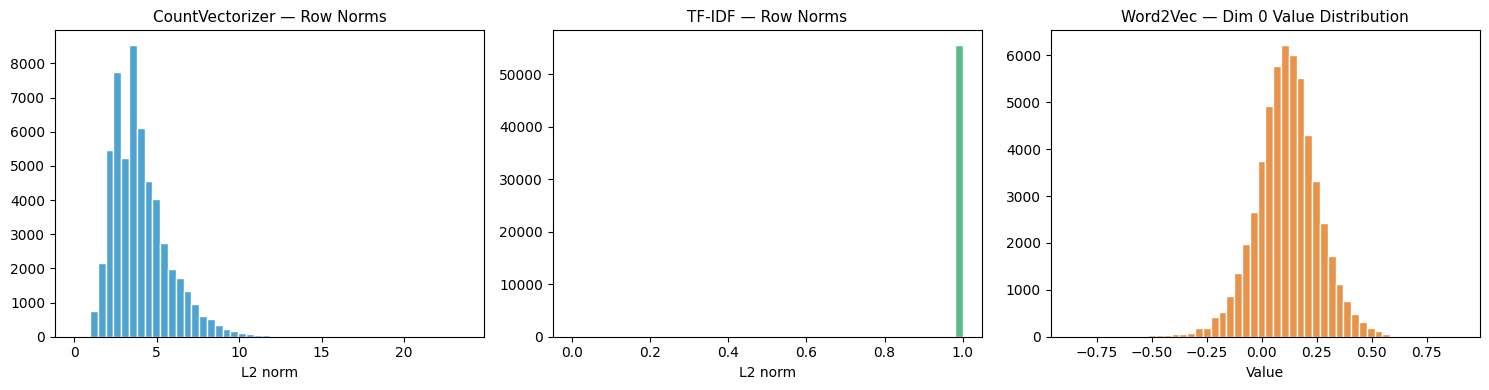

In [17]:
# Visual: distribution of vector norms per vectorizer
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# CountVec: row L2 norms
count_norms = np.asarray(X_train_count.power(2).sum(axis=1)).flatten() ** 0.5
axes[0].hist(count_norms, bins=50, color='#4FA3D1', edgecolor='white')
axes[0].set_title('CountVectorizer — Row Norms', fontsize=11)
axes[0].set_xlabel('L2 norm')

# TF-IDF: row L2 norms
tfidf_norms = np.asarray(X_train_tfidf.power(2).sum(axis=1)).flatten() ** 0.5
axes[1].hist(tfidf_norms, bins=50, color='#5DBB8A', edgecolor='white')
axes[1].set_title('TF-IDF — Row Norms', fontsize=11)
axes[1].set_xlabel('L2 norm')

# W2V: distribution of dim 0 values (just to show it's dense and continuous)
axes[2].hist(X_train_w2v[:, 0], bins=50, color='#E8924A', edgecolor='white')
axes[2].set_title('Word2Vec — Dim 0 Value Distribution', fontsize=11)
axes[2].set_xlabel('Value')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'vectorizer_norms.png'), dpi=120, bbox_inches='tight')
plt.show()

## 6. Summary

| Vectorizer | Dimensions | Type | Saved as |
|---|---|---|---|
| CountVectorizer | 50,000 | Sparse | `X_train_count.npz`, `X_test_count.npz` |
| TF-IDF | 50,000 | Sparse | `X_train_tfidf.npz`, `X_test_tfidf.npz` |
| Word2Vec (mean) | 100 | Dense | `X_train_w2v.npy`, `X_test_w2v.npy` |

**Next:** Phase 3 — Base Model Training (`03_base_models.ipynb`)